In [1]:
import numpy as np
import torch

# 2-Layer ReLU Network, Random Data, L2 Loss

In [ ]:
# N = numero esempi dataset // D_in = dimensione input // H = numero neuroni hidden layer // D_out = dimensione output
N, D_in, H, D_out = 64, 1000, 100, 10

# Creazione input e target
x = torch.randn(N, D_in)        # x --> tensore (64, 1000)
y = torch.randn(N, D_out)       # y --> tensore (64, 10)

# torch.nn.Sequential crea una pipeline di layer eseguiti uno dopo l'altro

# Input
#   |
# Linear
#   |
# ReLU
#   |
# Linear
#   |
# Output

model = torch.nn.Sequential(
    # Layer fully-connected che calcola h = xW + b, dove W = (1000 x 100) e b = (100)
    torch.nn.Linear(D_in, H),
    # Layer ReLU --> ReLU(x) = max(0, x)
    torch.nn.ReLU(),
    # Layer fully-connected che calcola y_pred = hW_2 + b_2
    torch.nn.Linear(H, D_out)
)


# learning rate: qunato velocemente la rete aggiorna i pesi
learning_rate = 1e-4

# optimizer: algoritmo di ottimizzazione dei parametri
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# addestra la rete per 500 iterazioni
for t in range(500):
    y_pred = model(x)
    loss = torch.nn.functional.mse_loss(y_pred, y)
    
    loss.backward()             # backpropagation
    
    optimizer.step()            # aggiorna pesi usando i gradienti --> w = w - lr*grad_loss
    optimizer.zero_grad()       # azzera il gradiente per lo step successivo (altrimenti si accumulano)

# Custom MLP Class with One Hidden Layer

In [2]:
from torch import nn
from torch.nn import functional as F
import cv2

In [ ]:
class MLP(nn.Module):
    # Dichiarare un layer con i parametri del modello
    def __init__(self):
        # Chiamare il costruttore della classe genitore (Module) per eseguire l'inizializzazione
        # In questo modo gli argomenti di altre funzioni possono anche essere speficicati
        # durante l'istanziazione della classe (come i parametri del modello)
        super().__init__()
        self.hidden = nn.Linear(20, 256)
        self.out = nn.Linear(256, 10)
        
    # forward propagation del modello
    def forward(self, X):
        return self.out(F.relu(self.hidden(X)))
        

# Residual-Block

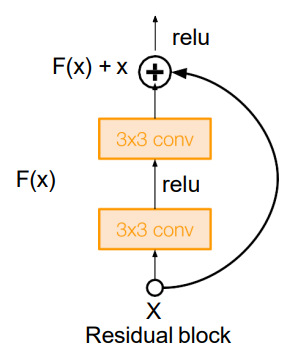

In [3]:
class ResidualBlock(nn.Module):
    
    # costruttore
    def __init__(self, inplanes, planes, stride = 1):
        super().__init__()
        
        # F(x)
        self.F = nn.Sequential(
            nn.Conv2d(inplanes, planes, 3, stride, 1, bias=False),
            nn.BatchNorm2d(planes),
            nn.ReLU(),
            nn.Conv2d(planes, planes, 3, 1, 1, bias=False),
            nn.BatchNorm2d(planes)
        )
        
        # G(x)
        if inplanes != planes or stride > 1:
            self.G = nn.Sequential(
                nn.Conv2d(inplanes, planes, 1, stride, 0, bias=False),
                nn.BatchNorm2d(planes)
                )
        else:
            self.G = None
        

    
    def forward(self, X):
        
        if self.G is None:
            G = X
        else:
            G = self.G(X)
              
        out = self.F(X)
        
        out = out + G
        
        return F.relu(out)

In [ ]:
# La batch normalization è una normalizzazione che serve per stabilizzare il training
# Normalizza i dati durante il training (BatchNorm2d lo fa per ogni canale)

# QUI NON VIENE FATTO TRAINING: la classe è solo un Residual Block
# --> quindi i kernel sono casuali, e non viene fatta nessuna backward() o ottimizzazione dei parametri

#### RANDOM DATA TESTING

In [4]:
# input 
# channels = 64, H = W = 32
x = torch.randn(1,64, 32, 32)

In [5]:
# match
# Con kernel=(3, 3) e padding=1 le dimensioni spaziali (H e W) non cambiano!
# Questo vale per ogni convoluzione
block = ResidualBlock(64, 64, stride=1)
y = block.forward(x)
print(y.shape)

torch.Size([1, 64, 32, 32])


In [6]:
# mismatch
# riduce H e W perché stride=2
block = ResidualBlock(64, 128, stride=2)
y = block.forward(x)
print(y.shape)

torch.Size([1, 128, 16, 16])


#### REAL-IMAGE TESTING

In [7]:
from PIL import Image
import matplotlib.pyplot as plt

In [8]:
# image opening and pre-processing
input = Image.open('lenna.jpg')

input = torch.from_numpy(np.array(input, dtype=np.float32)).permute(2, 0, 1)
input = input.unsqueeze(0)
input = input.to(torch.float32)

# input shape: (batch, inplanes, H, W)
print("input shape:", input.shape)

input shape: torch.Size([1, 3, 512, 512])


In [9]:
# match (inplanes = planes and stride=1 --> G(x) = X)
block = ResidualBlock(3, 3, stride=1)
y = block.forward(input)
print(y.shape)

torch.Size([1, 3, 512, 512])


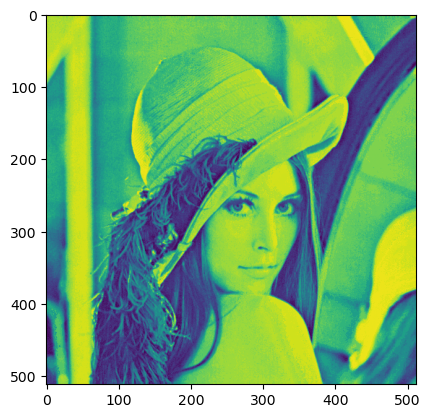

In [10]:
# INPUT
plt.imshow(y[0, 0].detach().numpy())

In [11]:
# mismatch (inplanes != planes or stride > 1 --> G(X) = projection(X))
block = ResidualBlock(3, 16, stride=2)
y = block.forward(input)
print(y.shape)

torch.Size([1, 16, 256, 256])


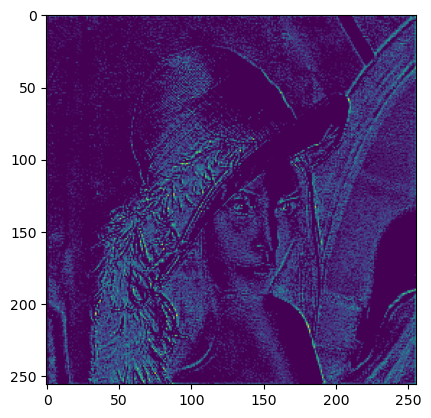

In [12]:
plt.imshow(y[0, 0].detach().numpy())